### TO DO

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import griddata
# import xesmf as xe
from pathlib import Path
import cartopy.crs as ccrs
import netCDF4  
import time
# import mpl_toolkits.basemap
# import pyresample
import utils as u

/home/fainx/micromamba/envs/xav_2412/lib/python3.11/site-packages/pyproj/__init__.py:95: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [4]:
year_list = ["2003"]#,"2004","2005","2006","2007","2008","2009","2010","2011","2012","2013"]
month_list = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
season_list = ["DJF","MAM","JJA","SON"]

In [5]:
# Domain study: Fedchenko, GRa
longitude=slice(66,78)
latitude=slice(36,42)
# temp_HMA=ds.sel(lat=lat,lon=lon)

#### Load MAR outputs

In [6]:
# MAR topography
coord = xr.open_dataset('/home/amoryc/NST.2000.01.01.00.GRa_Fedchenko.nc')
lon = coord.LON
lat = coord.LAT
H = coord.SH

In [7]:
# MAR dataset
folder = '/bettik/amoryc/MARout/GRf/spin3/work/'

# Surface temperature
t2m_yr = xr.open_dataset(folder+'year-TT-MARv3.14_ER5-2003-2013.nc')
t2m_mon = xr.open_dataset(folder+'mon-TT-MARv3.14_ER5-2003-2013.nc')

# Rain
wpr_yr = xr.open_dataset(folder+ 'year-RF-MARv3.14_ER5-2003-2013.nc')
wpr_mon = xr.open_dataset(folder+ 'mon-RF-MARv3.14_ER5-2003-2013.nc')

# Snow fall
spr_yr = xr.open_dataset(folder+ 'year-SF-MARv3.14_ER5-2003-2013.nc')
spr_mon = xr.open_dataset(folder+ 'mon-SF-MARv3.14_ER5-2003-2013.nc')

# Snow height
sh_yr = xr.open_dataset(folder+ 'year-SHSN3-MARv3.14_ER5-2003-2013.nc')
sh_mon = xr.open_dataset(folder+ 'mon-SHSN3-MARv3.14_ER5-2003-2013.nc')

### Load Observations

In [8]:
# CRU, APHRODITE SNOW-CCI => Maria a déjà tout sur Spirit

In [8]:
# CRU : Surface mean/min/max températures, clouds
folder_cru='/bettik/PROJECTS/pr-regional-climate/observations/CRU/'

tmp_cru = xr.open_mfdataset(folder_cru + '*.tmp.dat.nc', combine='by_coords', parallel=True).sel(lat=latitude,lon=longitude).load()
tmn_cru = xr.open_mfdataset(folder_cru + '*.tmn.dat.nc', combine='by_coords', parallel=True).sel(lat=latitude,lon=longitude).tmn.load()
tmx_cru = xr.open_mfdataset(folder_cru + '*.tmx.dat.nc', combine='by_coords', parallel=True).sel(lat=latitude,lon=longitude).tmx.load()
cld_cru = xr.open_mfdataset(folder_cru + '*.cld.dat.nc', combine='by_coords', parallel=True).sel(lat=latitude,lon=longitude).cld.load()

In [14]:
lats = tmp_cru.lat
lons = tmp_cru.lon

In [18]:
t2m_yr_regrid = t2m_yr.interp(Y=lats).interp(X=lons)

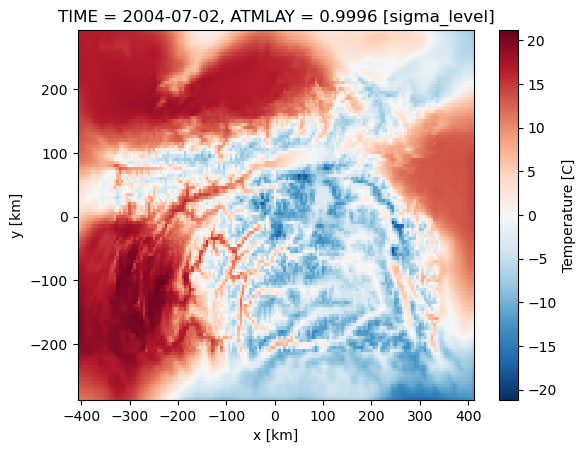

In [37]:
t2m_yr.TT.isel(ATMLAY=1).isel(TIME=1).plot()

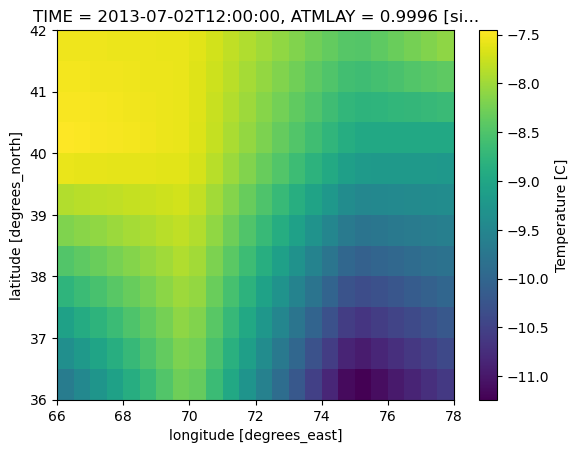

In [36]:
t2m_yr_regrid.TT.isel(TIME=10).isel(ATMLAY=1).plot()

In [9]:
lon = tmp_cru.lon.values
lat = tmp_cru.lat.values
data = tmp_cru.tmp.values

In [12]:
points = np.array([lon.flatten(), lat.flatten()])
values = data.flatten()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [ ]:
prec_orig=np.array(tmp_cru.tmp[10,:,:])

In [ ]:
tmp_cru_orig= tmp_cru.tmp[0,:,:]
tmp_cru_orig

In [ ]:
longitudes=t2m_mon.X
latitudes=t2m_mon.Y

In [ ]:
lon_orig = tmp_cru.lon.values.flatten()  # Longitude
lat_orig = tmp_cru.lat.values.flatten()  # Latitude
tmp_cru_orig

In [ ]:
interp_obs_tmp[0,:,:]=griddata((lon_orig,lat_orig),tmp_cru_orig,(longitudes,latitudes),method='linear')SAFRANtoMAR = griddata((lons,lats),imarray.flatten(),(longitudes,latitudes),method='nearest')

In [ ]:
SAFRANtoMAR = griddata((lons,lats),imarray.flatten(),(longitudes,latitudes),method='nearest')

In [ ]:
 # Obs
        obs_precip[indexyear,:,:]=np.mean(monthly_obs,axis=(0)) # Annual mean
        # Interpolation of the observational data on the MAR grid
        x_orig=lon_obs.flatten(); y_orig=lat_obs.flatten()
        prec_orig=np.array(obs_precip[indexyear,:,:]).flatten()
        interp_obs_precip[indexyear,:,:]=griddata((x_orig,y_orig),prec_orig,(longitudes,latitudes),method='linear')


In [ ]:
# Test d'interpolation CRU => MAR

result = mpl_toolkits.basemap.interp(tmp_cru, tmp_cru.lon, tmp_cru.lat, t2m_mon.X, t2m_mon.Y,
                                     checkbounds=False, masked=False, order=1)

In [ ]:
tmx_cru.groupby("time.season").mean('time').sel(season=season_list[1]).plot()

### Load ERA5

In [ ]:
folder_era5 = '/bettik/PROJECTS/pr-regional-climate/observations/ERA5/'
ds_era5 = xr.open_mfdataset(folder_era5 + 'era5_GRa.nc')

In [ ]:
#Open and combine all ERA5 dataset
# => better to do it with CDO.. because lack of mem

for i in range(len(year_list)):
    folder_year=year_list[i]
    path_era5_t2m = Path(folder_out_era5 + 'ds_era5_t2m_' + folder_year + '.nc')
        
    if path_era5_t2m.is_file():
        print(f'The file {path_era5_t2m} already exists')
        ds_era5_t2m = xr.open_mfdataset(folder_out_era5 + 'ds_era5_t2m_' + folder_year + '.nc', parallel=True).tas.load()
    else:
        print(f'The file {path_era5_t2m} does not exist')
        print(f'Extracting ERA5 data')
        ds_era5_t2m= xr.open_mfdataset(folder_era5 + folder_year + '/'+ file_ERA5,  combine='by_coords', parallel=True).T #concat_dim ='time',
        # ds_era5_t2m.to_netcdf(folder_out_era5 + 'ds_era5_t2m_' + folder_year + '.nc')

### Load ERA5-Land

In [ ]:
folder_era5_land='/bettik/PROJECTS/pr-regional-climate/observations/ERA5-land/'
ds_era5_land = xr.open_mfdataset(folder_era5_land + 'era5_land_GRa.nc')

In [ ]:
ds_era5

### First Plot

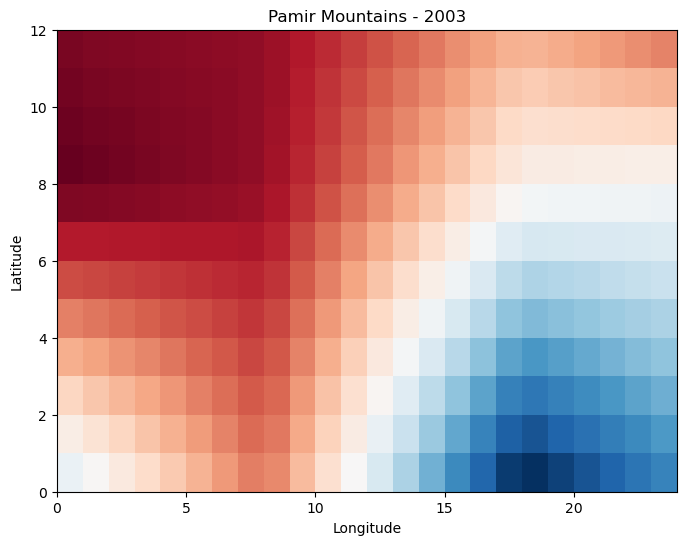

In [30]:
plt.figure(figsize=(8, 6))  
mesh = plt.pcolormesh(t2m_yr_regrid.TT.isel(TIME=0).isel(ATMLAY=0), cmap='RdBu_r')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Pamir Mountains - 2003")

# levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 
# contours = plt.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)

# # labels sur les courbes de niveau
# plt.clabel(contours, inline=True, fontsize=8, fmt='%d m') 

# cbar = plt.colorbar(mesh)
# cbar.set_label("Mean annual temperature (°C)")

plt.show()

/tmp/ipykernel_2010805/2406091145.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = plt.pcolormesh(coord.LON, coord.LAT, t2m_yr.TT.isel(TIME=0).isel(ATMLAY=0), cmap='RdBu_r')


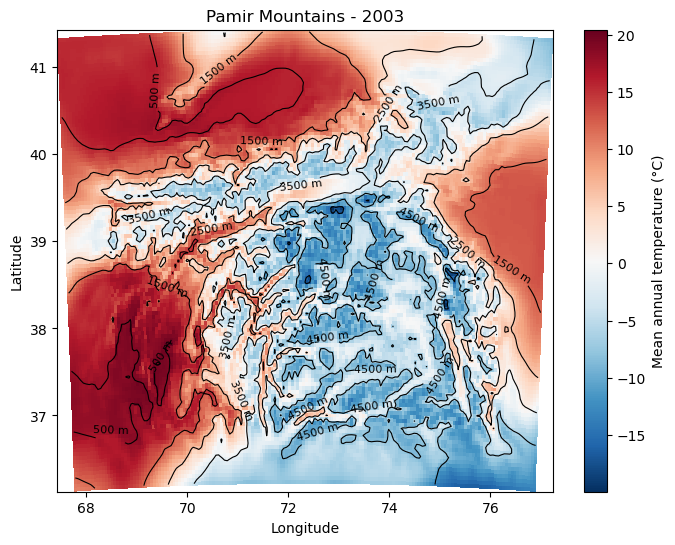

In [29]:
plt.figure(figsize=(8, 6))  
mesh = plt.pcolormesh(coord.LON, coord.LAT, t2m_yr.TT.isel(TIME=0).isel(ATMLAY=0), cmap='RdBu_r')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Pamir Mountains - 2003")

levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 
contours = plt.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)

# labels sur les courbes de niveau
plt.clabel(contours, inline=True, fontsize=8, fmt='%d m') 

cbar = plt.colorbar(mesh)
cbar.set_label("Mean annual temperature (°C)")

plt.show()

/tmp/ipykernel_507469/3039237409.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(coord.LON, coord.LAT, t2m_yr.TT.isel(TIME=i).isel(ATMLAY=0), cmap='RdBu_r', shading='auto')
/tmp/ipykernel_507469/3039237409.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


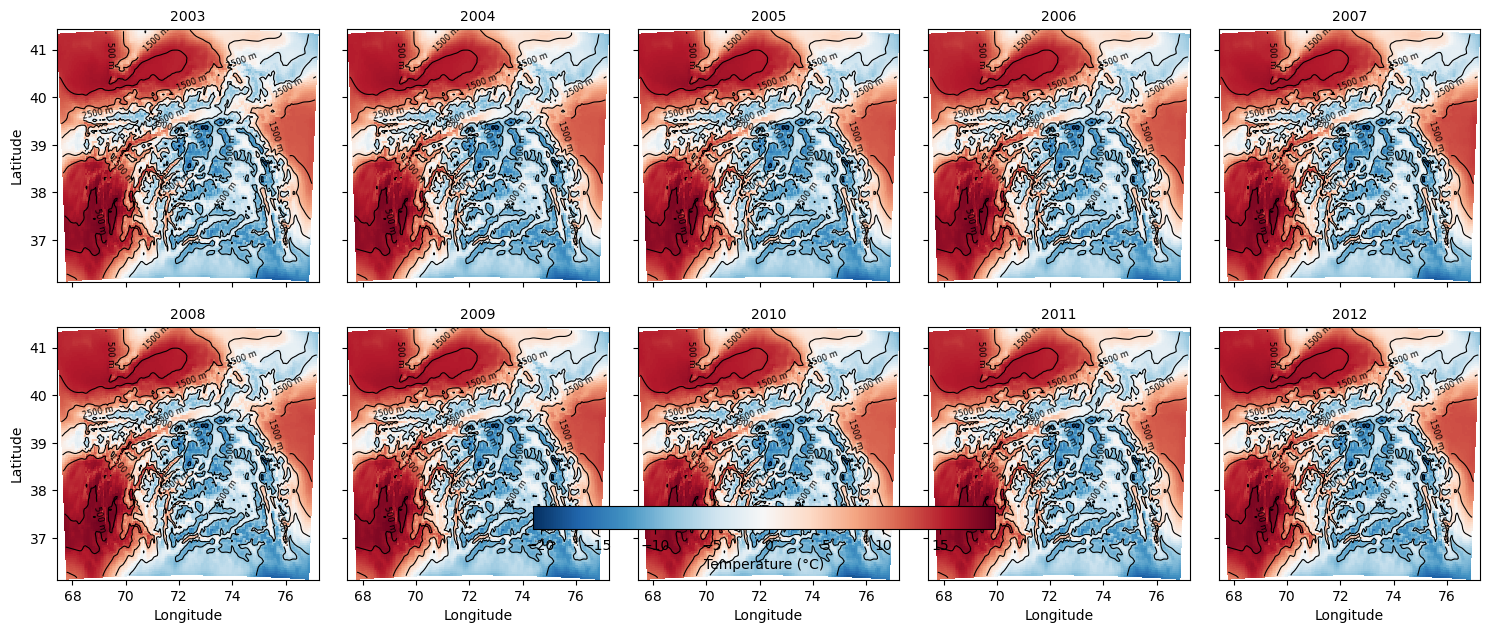

In [16]:
years = np.arange(2003, 2013) #2013 dataset not shown

fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharex=True, sharey=True)

for i, ax in enumerate(axes.flat):
    mesh = ax.pcolormesh(coord.LON, coord.LAT, t2m_yr.TT.isel(TIME=i).isel(ATMLAY=0), cmap='RdBu_r', shading='auto')
    
    levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m
    contours = ax.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)
    ax.clabel(contours, inline=True, fontsize=6, fmt='%d m')

    ax.set_title(f"{years[i]}", fontsize=10)

    # Axes (seulement pour les bords)
    if i % 5 == 0:
        ax.set_ylabel("Latitude")
    if i >= 5:
        ax.set_xlabel("Longitude")


cbar = fig.colorbar(mesh, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label("Temperature (°C)")

# Ajustement des espacements
plt.tight_layout()

plt.show()

# Seasonnal variability

## Surface Temperature

#### Add comparison with CRU, ERA5, including differences (MAR-CRU..)

In [17]:
#A travailler : interpolation entre grilles lat/lon et MAR

t2m_mon_regrid = t2m_mon.TT.isel(ATMLAY=0).interp(lat=tmx_cru['lat'], lon = tmx_cru['lon'])

ValueError: Dimensions {'lat', 'lon'} do not exist. Expected one or more of FrozenMappingWarningOnValuesAccess({'TIME': 132, 'X': 164, 'Y': 116})

In [ ]:
nrows=4
ncols=3



fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(10, 14)) 
j=0
k=0

column_titles = ["MAR", "CRU", "Difference MAR - CRU"]
row_titles = season_list


for i, ax in enumerate(axes.flat):
    if (i) % 3 == 0 : 
        m = ax.pcolormesh(coord.LON, coord.LAT,t2m_mon.TT.isel(ATMLAY=0).groupby("TIME.season").mean('TIME').sel(season=season_list[j]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
        j=j+1
    elif (i-1) % 3 == 0 : 
         m = ax.pcolormesh(tmx_cru['lon'], tmx_cru['lat'],tmx_cru.groupby("time.season").mean('time').sel(season=season_list[k]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
         k=k+1
        
        
    levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m
    contours = ax.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)
    ax.clabel(contours, inline=True, fontsize=6, fmt='%d m')

for col in range(ncols):
    axes[0, col].set_title(column_titles[col], fontsize=12, fontweight='bold')
for row in range(nrows):
    fig.text(0.02, 0.78 - row * 0.22, row_titles[row], fontsize=12, fontweight='bold', rotation=90, va='center')

    
fig.suptitle('Mean seasonnal (2003-2014) surface temperature : MAR vs CRU', fontsize=12)

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7]) 
fig.colorbar(mesh, cax=cbar_ax, orientation='vertical', label='Temperature (°C)')

plt.tight_layout()
plt.show()

#### Comparing MAR and ERA5-LAND

In [ ]:
nrows=4
ncols=3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(10, 14)) 
j=0
k=0

for i, ax in enumerate(axes.flat):
    if (i) % 3 == 0 : 
        m = ax.pcolormesh(coord.LON, coord.LAT,t2m_mon.TT.isel(ATMLAY=0).groupby("TIME.season").mean('TIME').sel(season=season_list[j]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
        j=j+1
    elif (i-1) % 3 == 0 : 
         m = ax.pcolormesh(ds_era5_land['longitude'], ds_era5_land['latitude'], ds_era5_land.t2m.groupby("valid_time.season").mean('valid_time').sel(season=season_list[k])-273.15, cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
         k=k+1
        
# ds_era5.t.isel(valid_time=1).isel(pressure_level=0).plot()
    levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m
    contours = ax.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)
    ax.clabel(contours, inline=True, fontsize=6, fmt='%d m')
    
fig.suptitle('Mean seasonnal (2003-2014) temperature : MAR vs ERA5-LAND', fontsize=12)

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7]) 
fig.colorbar(mesh, cax=cbar_ax, orientation='vertical', label='Temperature (°C)')

plt.tight_layout()
plt.show()

#### Comparing MAR and ERA5

/tmp/ipykernel_507469/1986612807.py:12: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(coord.LON, coord.LAT,t2m_mon.TT.isel(ATMLAY=0).groupby("TIME.season").mean('TIME').sel(season=season_list[j]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
/tmp/ipykernel_507469/1986612807.py:12: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(coord.LON, coord.LAT,t2m_mon.TT.isel(ATMLAY=0).groupby("TIME.season").mean('TIME').sel(season=season_list[j]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
/tmp/ipykernel_507469/1986612807.py:12: UserWarning: The

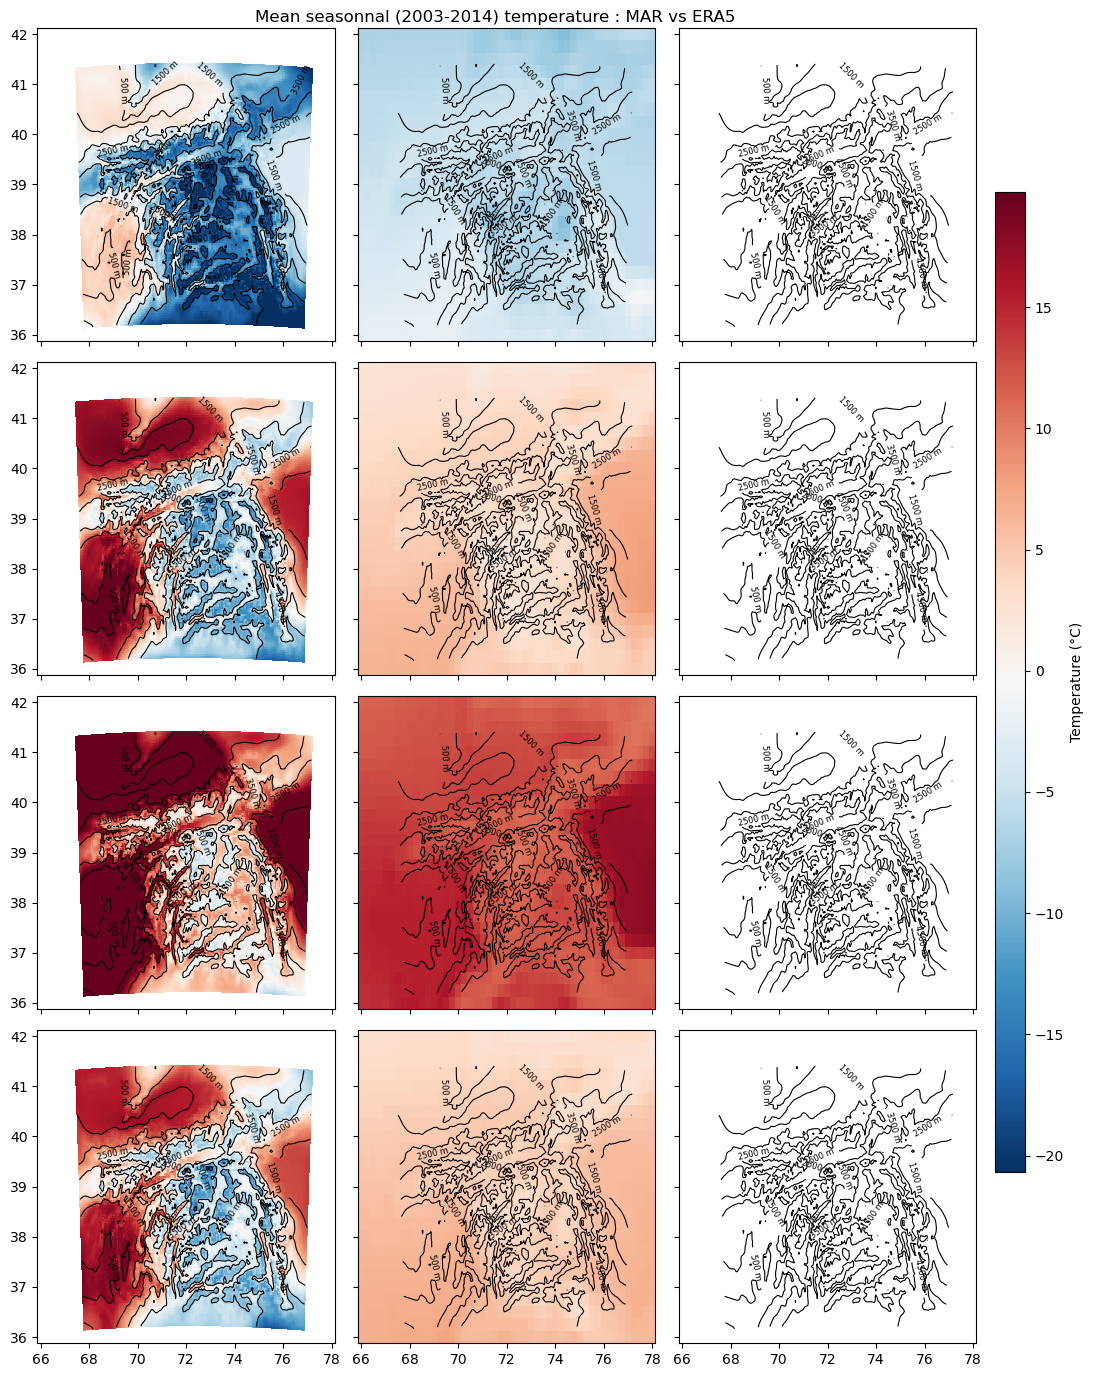

In [18]:
#Vérifier le sens de 'pressure_level'

nrows=4
ncols=3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(10, 14)) 
j=0
k=0

for i, ax in enumerate(axes.flat):
    if (i) % 3 == 0 : 
        m = ax.pcolormesh(coord.LON, coord.LAT,t2m_mon.TT.isel(ATMLAY=0).groupby("TIME.season").mean('TIME').sel(season=season_list[j]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
        j=j+1
    elif (i-1) % 3 == 0 : 
         m = ax.pcolormesh(ds_era5['longitude'], ds_era5['latitude'], ds_era5.t.isel(pressure_level=10).groupby("valid_time.season").mean('valid_time').sel(season=season_list[k])-273.15, cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
         k=k+1
        
# ds_era5.t.isel(valid_time=1).isel(pressure_level=0).plot()
    levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m
    contours = ax.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)
    ax.clabel(contours, inline=True, fontsize=6, fmt='%d m')
    
fig.suptitle('Mean seasonnal (2003-2014) temperature : MAR vs ERA5', fontsize=12)

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7]) 
fig.colorbar(mesh, cax=cbar_ax, orientation='vertical', label='Temperature (°C)')

plt.tight_layout()
plt.show()

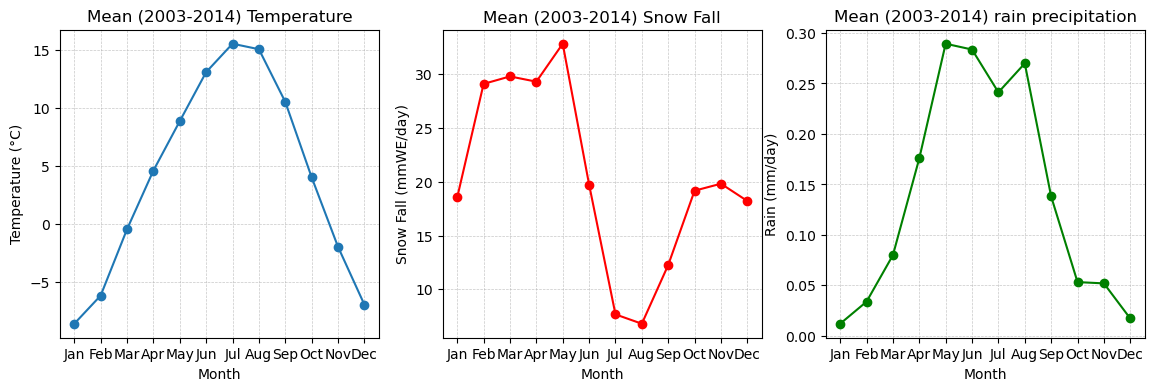

In [19]:
#Ajouter une dépendance à l'altitude

nrows=1
ncols=3

fig, ax = plt.subplots(nrows=nrows, ncols=ncols,  figsize=(14, 4)) 

ax[0].plot(t2m_mon.TT.isel(ATMLAY=0).groupby('TIME.month').mean('TIME').mean(('X', 'Y')),marker='o', linestyle='-')

ax[0].set_xticks(np.arange(0, 12))
ax[0].set_xticklabels(month_list)

ax[0].set_xlabel("Month")
ax[0].set_ylabel("Temperature (°C)")
ax[0].set_title("Mean (2003-2014) Temperature")
ax[0].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

ax[1].plot(spr_mon.SF.groupby('TIME.month').mean('TIME').mean(('X', 'Y')),marker='o', linestyle='-', color = 'r')

ax[1].set_xticks(np.arange(0, 12))
ax[1].set_xticklabels(month_list)

ax[1].set_xlabel("Month")
ax[1].set_ylabel("Snow Fall (mmWE/day)")
ax[1].set_title("Mean (2003-2014) Snow Fall")
ax[1].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

ax[2].plot(wpr_mon.RF.groupby('TIME.month').mean('TIME').mean(('X', 'Y')),marker='o', linestyle='-', color = 'g')

ax[2].set_xticks(np.arange(0, 12))
ax[2].set_xticklabels(month_list)

ax[2].set_xlabel("Month")
ax[2].set_ylabel("Rain (mm/day)")
ax[2].set_title("Mean (2003-2014) rain precipitation")
ax[2].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

plt.show()

## Snow Pack Characteristics

##### Need to include comparison with SNOW-CCI

/tmp/ipykernel_507469/1796893423.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(coord.LON, coord.LAT,sh_mon.SHSN3.groupby("TIME.season").mean('TIME').isel(SECTOR=1).sel(season=season_list[i]), shading='auto',  vmin=0, vmax=8)
/tmp/ipykernel_507469/1796893423.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(coord.LON, coord.LAT,sh_mon.SHSN3.groupby("TIME.season").mean('TIME').isel(SECTOR=1).sel(season=season_list[i]), shading='auto',  vmin=0, vmax=8)
/tmp/ipykernel_507469/1796893423.py:7: UserWarning: The input coordinates to pcolorm

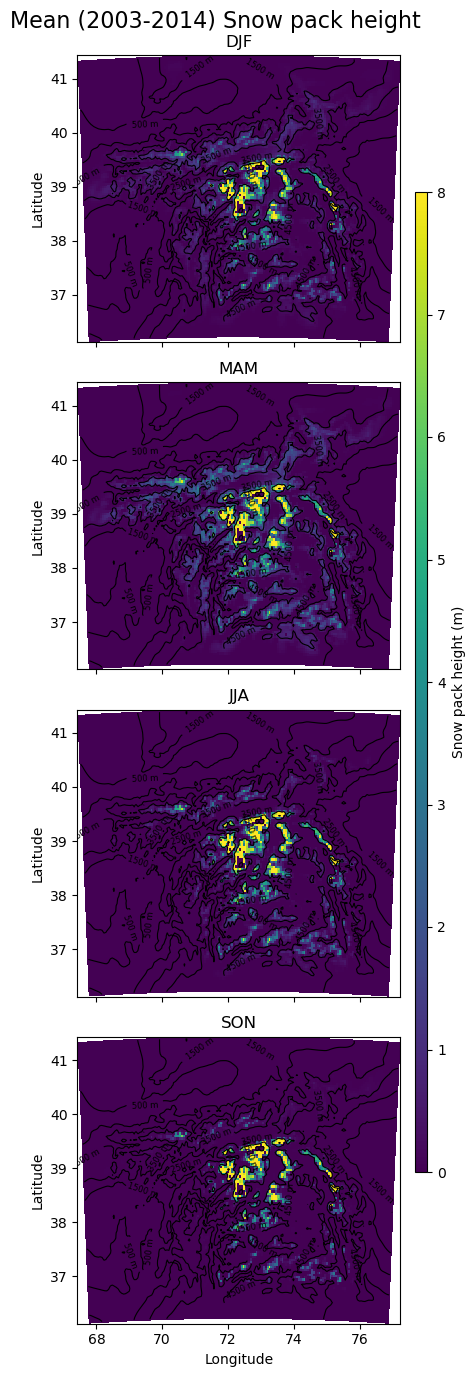

In [20]:
nrows=4
ncols=1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(4, 14)) 

for i, ax in enumerate(axes.flat):
    mesh = ax.pcolormesh(coord.LON, coord.LAT,sh_mon.SHSN3.groupby("TIME.season").mean('TIME').isel(SECTOR=1).sel(season=season_list[i]), shading='auto',  vmin=0, vmax=8)
    
    levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m
    contours = ax.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)
    ax.clabel(contours, inline=True, fontsize=6, fmt='%d m')
    
    ax.set_title(season_list[i]) 
    ax.set_ylabel('Latitude') 
    # if i % 5 == 0:
    #     axs[i].set_ylabel("Latitude")
    if i >= 3:
        ax.set_xlabel("Longitude")

fig.suptitle('Mean (2003-2014) Snow pack height', fontsize=16)

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7]) 
fig.colorbar(mesh, cax=cbar_ax, orientation='vertical', label='Snow pack height (m)')

plt.tight_layout()
plt.show()

In [21]:
1+1

2